# P9 — Does the regime layer pay rent? (gate N7)

**Question:** over the honest walk-forward (1972–2020, point-in-time data, 10 bps costs), does
tilting the core mix by the regime belief beat the same mix with the tilt switched off, by enough
to survive the multiple-testing hurdle?

Everything below is read from tracked outputs of the last budgeted run (8.1's D-04 run, registry
tag `08.1-pit-tilt-vs-ablation`). Only the three price baselines are recomputed, by deterministic
arithmetic with no registry trial. Nothing is fitted.

**Prerequisites — run these first if the artifacts below are missing:**

- `python scripts/build_platform_data.py` (the `monthly_raw` the baselines are rebuilt from)
- the backtest outputs are tracked; a budgeted `python -m trading_crab_lib.platform.evaluation.report`
  run is the only thing that rewrites them


In [1]:
%matplotlib inline
import contextlib
import io
import logging
import shutil

import numpy as np
from IPython.display import Markdown, display

logging.basicConfig(level=logging.WARNING)

from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform.honesty.registry import total_trial_count
from trading_crab_lib.platform.evaluation.deflated_sharpe import expected_max_sharpe, quality_tier
from trading_crab_lib.platform.plotting import backtest as pbacktest
from trading_crab_lib.platform.report import scoreboard

REPORT_HINT = "python -m trading_crab_lib.platform.evaluation.report"
DATA_HINT = "python scripts/build_platform_data.py"

cfg = load_platform_config()
safe_cfg = pplot.redacted_config(cfg)  # never display cfg itself (T-06-01)
print("cost:", safe_cfg["backtest"]["cost_bps"], "bps; scoreboard tag:", safe_cfg["report"]["scoreboard_trial_tag"])
n_trials = total_trial_count()
print("registry trials (live):", n_trials)


cost: 10 bps; scoreboard tag: 08.1-pit-tilt-vs-ablation
registry trials (live): 46


## 1. Before and after the point-in-time fix (E-06)

The 8.1 audit rebuilt the inputs point in time. "Before" is the pre-audit run, kept in
`pit_08.1/before/`; "after" is the run the scoreboard reads.


In [2]:
before = pplot.load_report_artifact("pit_08.1/before/backtest_kpi_table.parquet", rebuild_hint=REPORT_HINT)
after = pplot.load_report_artifact("backtest_kpi_table.parquet", rebuild_hint=REPORT_HINT)
before_after = scoreboard.before_after_table(before, after)
print(before_after.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


               leg  tlw_before  tlw_after  tlw_delta  mdd_before  mdd_after  mdd_delta
          strategy      4.2157     3.8909    -0.3248     -0.3104    -0.2390     0.0713
no_regime_ablation      4.0480     4.0424    -0.0057     -0.1976    -0.1983    -0.0008
      spy_buy_hold      5.6805     5.6882     0.0077     -0.4895    -0.4917    -0.0022
       sixty_forty      5.0471     5.0404    -0.0066     -0.2696    -0.2715    -0.0018
         faber_sma      6.3726     6.4285     0.0559     -0.1894    -0.1898    -0.0003


## 2. The scoreboard, as the weekly page prints it

All five legs on the same months (the strategy curve's window); the KPI table's own-span numbers
are a footnote because the baselines start ten years earlier.


In [3]:
board = scoreboard.scoreboard_table(cfg)
assert board["reconciled"], board["reason"]
display(Markdown("\n".join(scoreboard.format_scoreboard(board))))


## Scoreboard (static — last budgeted run)

| Leg | TLW 1972–2020 | MDD 1972–2020 |
|---|---|---|
| Regime tilt (strategy) | 3.8909 | -23.90% |
| No-regime ablation | 4.0424 | -19.83% |
| SPY buy & hold | 5.0022 | -49.17% |
| 60/40 | 4.4799 | -27.15% |
| Faber 10-mo SMA | 5.5451 | -18.98% |

Own-span TLW (backtest_kpi_table.parquet): Regime tilt (strategy) 3.8909; No-regime ablation 4.0424; SPY buy & hold 5.6882 (from 1962-05); 60/40 5.0404 (from 1962-05); Faber 10-mo SMA 6.4285 (from 1962-02). The table above puts all five legs on the same months, so its numbers are comparable; the own-span ones are not.

Run 2026-09-30 (registry tag 08.1-pit-tilt-vs-ablation) · window 1972-01-31 → 2020-12-31 · 588 monthly steps · 10 bps

Caveat (E-07): scoreboard returns use monthly-average prices for equities, oil and long duration, which may flatter trend and tilt rules.


## 3. Five equity curves on the common window

strategy             588 months 1972-01-31 -> 2020-12-31
no_regime_ablation   588 months 1972-01-31 -> 2020-12-31
spy_buy_hold         588 months 1972-01-31 -> 2020-12-31
sixty_forty          588 months 1972-01-31 -> 2020-12-31
faber_sma            588 months 1972-01-31 -> 2020-12-31


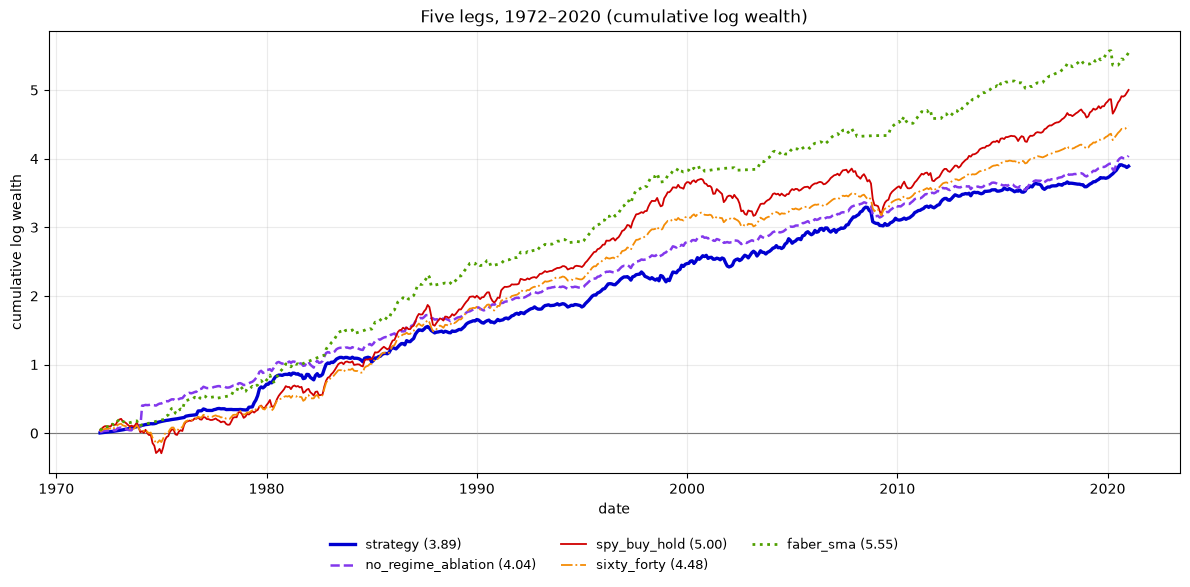

In [4]:
strategy_curve = pplot.load_report_artifact("backtest_equity_curve_strategy.parquet", rebuild_hint=REPORT_HINT)
ablation_curve = pplot.load_report_artifact("backtest_equity_curve_ablation.parquet", rebuild_hint=REPORT_HINT)
monthly_raw = pplot.load_platform_checkpoint("monthly_raw", rebuild_hint=DATA_HINT)
baselines = pbacktest.recompute_baseline_curves(monthly_raw, cfg)
window = strategy_curve.index
curves = {
    "strategy": strategy_curve["return"],
    "no_regime_ablation": ablation_curve["return"],
    **{name: series.loc[window[0]:window[-1]] for name, series in baselines.items()},
}
for name, series in curves.items():
    print(f"{name:<20} {len(series.dropna())} months {series.index.min().date()} -> {series.index.max().date()}")
fig_curves = pbacktest.plot_equity_curves(
    curves, title=f"Five legs, {window[0].year}–{window[-1].year} (cumulative log wealth)"
)


## 4. Sharpe against the deflated-Sharpe hurdle

A leg "pays" only if its annualized Sharpe clears `expected_max_sharpe(n_trials, variance)`: the
best Sharpe pure luck would produce after this many trials (ADR-0003, the A11 gate). The trial
count is the live registry count; the Sharpe variance is 1.0, E-06's placeholder.


hurdle at 46 trials: 2.2442
strategy             Sharpe 1.0685  DSR 0.0000  clears: False
no_regime_ablation   Sharpe 1.0529  DSR 0.0000  clears: False
spy_buy_hold         Sharpe 0.8738  DSR 0.0000  clears: False
sixty_forty          Sharpe 1.1638  DSR 0.0000  clears: False
faber_sma            Sharpe 1.2722  DSR 0.0000  clears: False


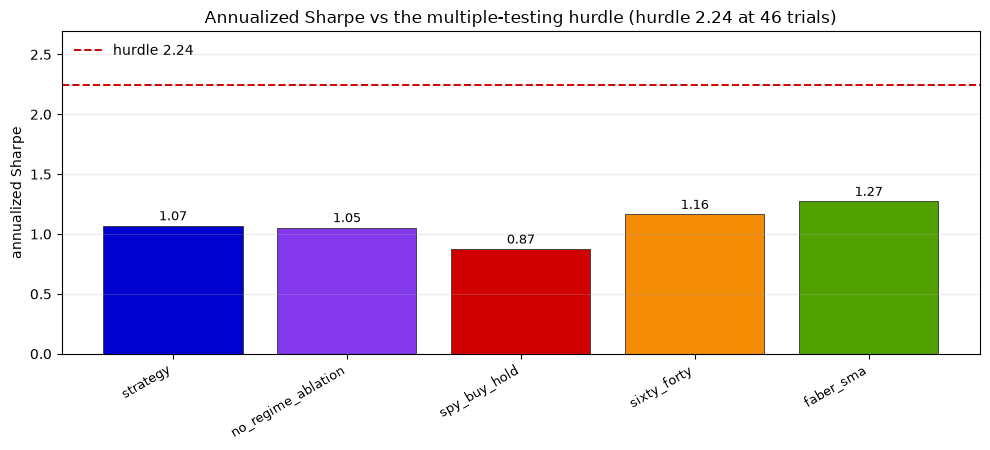

In [5]:
SHARPE_VARIANCE = 1.0
hurdle = expected_max_sharpe(n_trials, SHARPE_VARIANCE)
tiers = {name: quality_tier(series, n_trials=n_trials, sharpe_variance=SHARPE_VARIANCE) for name, series in curves.items()}
print(f"hurdle at {n_trials} trials: {hurdle:.4f}")
for name, tier in tiers.items():
    print(f"{name:<20} Sharpe {tier['observed_sharpe']:.4f}  DSR {tier['dsr']:.4f}  clears: {tier['ok']}")
fig_hurdle = pbacktest.plot_sharpe_vs_hurdle(
    {name: tier["observed_sharpe"] for name, tier in tiers.items()}, hurdle, n_trials=n_trials
)


In [6]:
print(scoreboard.E07_CAVEAT)

Caveat (E-07): scoreboard returns use monthly-average prices for equities, oil and long duration, which may flatter trend and tilt rules.


## 5. Guard: the answer below must still be true

If a later budgeted run rewrites the outputs so that the tilt beats the ablation, or either leg
clears the hurdle, this cell fails and the answer below must be revisited before sign-off.


In [7]:
tlw = {row["leg"]: row["tlw_common"] for row in board["legs"]}
assert tlw["strategy"] < tlw["no_regime_ablation"], "the tilt now beats the ablation: revisit the answer"
assert not tiers["strategy"]["ok"], "the tilt now clears the hurdle: revisit the answer"
assert not tiers["no_regime_ablation"]["ok"], "the ablation now clears the hurdle: revisit the answer"
assert total_trial_count() == n_trials, "a registry row was appended"
print(f"guard passed: tilt TLW {tlw['strategy']:.4f} < ablation TLW {tlw['no_regime_ablation']:.4f}; "
      f"neither clears the hurdle {hurdle:.4f} at {n_trials} trials")


guard passed: tilt TLW 3.8909 < ablation TLW 4.0424; neither clears the hurdle 2.2442 at 46 trials


## Answer

**No — the regime view stays advisory (G-06).**

Over 1972–2020 the regime tilt ends below the same mix without it: terminal log wealth 3.89 vs
4.04 and max drawdown −23.9% vs −19.8%. Its annualized Sharpe is marginally higher (about 1.07 vs
1.05), but neither leg comes near the multiple-testing hurdle (about 2.24 at 46 trials), so that
gap is noise. The point-in-time fix (section 1) cost the tilt about 0.32 of log wealth and the
ablation almost nothing. And the returns carry the E-07 caveat, which if anything flatters a tilt. The weekly page therefore trades the no-regime core
mix (A-13) and suspends the regime view until the regime-rebuild phase re-measures it.


## N7 Sign-Off

Glenn fills this in after reading the notebook top to bottom (D-15 style: a plain cell, no helper,
no ledger).

**Date:** _pending_

**Verdict:** _pending_ (approve / approve with notes / reject)

**Reasoning:** _pending_
